[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/doxav/astromodel_proving/blob/main/analysis/06_predictive_validation_and_perturbation.ipynb)

# Step 06 - Predictive validation and perturbation robustness

This notebook runs the local Step 06 pipeline without Google Drive dependencies and writes auditable outputs under `outputs/predictive_validation/`.

**Scope:** reviewer-facing validation uses all accepted cells by default (`candidate_policy='best_per_cell'`) and all six canonical currents for perturbations. This is a full cell-level validation scope: all accepted cells are represented by one best accepted candidate per cell, avoiding arbitrary candidate-row caps while preventing a candidate-rich cell from dominating the perturbation audit.

**Claim scope:** Step 06 may support a predictive/perturbation robustness screen, but it does not by itself authorize final biological degeneracy wording. Later assumption-sensitivity and parameter-plausibility steps remain required.

In [1]:
from pathlib import Path
import os
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path(os.environ.get("ASTROMODEL_PROJECT_ROOT", ".")).resolve()
PROJECT_ROOT

PosixPath('/home/xav/code/astromodel_proving')

In [2]:
from src.step06_predictive_validation import Step06Config, run_step06_predictive_validation

config = Step06Config(
    max_candidates=None,
    candidate_policy="best_per_cell",
    time_points=50,
    perturbation_current_na=None,
    write_outputs=True,
)
result = run_step06_predictive_validation(PROJECT_ROOT, config)
result["analysis_summary"]

/home/xav/code/astromodel_proving/src/astro_model.py:221: RuntimeWarning: overflow encountered in scalar multiply
  i_kir = g_kir * np.sqrt(max(abs(k_o), 1e-12)) * (va - e_k_a) / (1.0 + _safe_exp((va - e_k_a) / 19.2))


{'step_name': 'Step 06 — Predictive validation and perturbation robustness',
 'config': {'max_candidates': None,
  'candidate_policy': 'best_per_cell',
  'candidates_per_cell': 3,
  'time_points': 50,
  't_final_ms': 50000.0,
  'prediction_interval_quantiles': (0.05, 0.5, 0.95),
  'min_holdout_pass_fraction': 0.3,
  'max_trace_rmse_mV': 25.0,
  'perturbation_current_na': None,
  'perturbation_factors': {'nominal': 1.0,
   'eps_scale_low': 0.5,
   'eps_scale_high': 2.0,
   'stimulus_duration_short': 0.75,
   'stimulus_duration_long': 1.25,
   'baseline_K_o_low': 0.9,
   'baseline_K_o_high': 1.1,
   'current_scale_low': 0.75,
   'current_scale_high': 1.25},
  'robustness_recovery_error_max': 1.5,
  'robustness_peak_ratio_max': 1.75,
  'robustness_K_o_peak_max_mM': 15.0,
  'robustness_K_o_final_max_mM': 7.0,
  'min_perturbation_feature_pass_fraction': 0.25,
  'min_robust_fraction': 0.5,
  'write_outputs': True,
  'require_candidate_level_heldout': True,
  'final_degeneracy_claim_allowed':

## Accepted ensemble and mechanism inventory

In [3]:
heldout = result["heldout_current_errors"]
heldout[["file_id", "region", "condition", "candidate_id", "mechanism_cluster"]].drop_duplicates().head(10)

,file_id,region,condition,candidate_id,mechanism_cluster
0,1_DH_1_CONTROL,DH,CONTROL,1_DH_1_CONTROL__hybrid_optuna_087,M1
8,1_DH_2_CONTROL,DH,CONTROL,1_DH_2_CONTROL__hybrid_optuna_098,M1
16,1_VH_1_CONTROL,VH,CONTROL,1_VH_1_CONTROL__hybrid_optuna_004,M2
24,1_VH_2_CONTROL,VH,CONTROL,1_VH_2_CONTROL__hybrid_optuna_001,M2
32,2_DH_1_CONTROL,DH,CONTROL,2_DH_1_CONTROL__hybrid_optuna_096,M1
40,3_DH_1_CONTROL,DH,CONTROL,3_DH_1_CONTROL__hybrid_optuna_097,M1
48,3_DH_2_CONTROL,DH,CONTROL,3_DH_2_CONTROL__hybrid_optuna_098,M1
56,DH_1_CONTROL,DH,CONTROL,DH_1_CONTROL__hybrid_optuna_099,M1
64,DH_1_MFA,DH,MFA,DH_1_MFA__hybrid_optuna_057,M1
72,DH_1_MFA_BA,DH,MFA_BA,DH_1_MFA_BA__hybrid_optuna_094,M3


## Held-out-current error table

In [4]:
heldout.head(12)

,file_id,region,condition,candidate_id,sweep,current_na,split_strategy,heldout_trace_rmse_mV,heldout_weighted_feature_pass_fraction,holdout_status,prediction_status,prediction_pass,mechanism_cluster,mechanism_label_status
0,1_DH_1_CONTROL,DH,CONTROL,1_DH_1_CONTROL__hybrid_optuna_087,1,50,leave_one_current_out,7.581329,0.359609,passed,predictive_pass,True,M1,step05_label_available
1,1_DH_1_CONTROL,DH,CONTROL,1_DH_1_CONTROL__hybrid_optuna_087,2,75,leave_one_current_out,7.581329,0.359609,passed,predictive_pass,True,M1,step05_label_available
2,1_DH_1_CONTROL,DH,CONTROL,1_DH_1_CONTROL__hybrid_optuna_087,3,100,leave_one_current_out,7.581329,0.359609,passed,predictive_pass,True,M1,step05_label_available
3,1_DH_1_CONTROL,DH,CONTROL,1_DH_1_CONTROL__hybrid_optuna_087,4,125,leave_one_current_out,7.581329,0.359609,passed,predictive_pass,True,M1,step05_label_available
4,1_DH_1_CONTROL,DH,CONTROL,1_DH_1_CONTROL__hybrid_optuna_087,5,150,leave_one_current_out,7.581329,0.359609,passed,predictive_pass,True,M1,step05_label_available
5,1_DH_1_CONTROL,DH,CONTROL,1_DH_1_CONTROL__hybrid_optuna_087,6,175,leave_one_current_out,7.581329,0.359609,passed,predictive_pass,True,M1,step05_label_available
6,1_DH_1_CONTROL,DH,CONTROL,1_DH_1_CONTROL__hybrid_optuna_087,-1,162,low_to_high,7.581329,0.359609,stress_test_screen,predictive_pass,True,M1,step05_label_available
7,1_DH_1_CONTROL,DH,CONTROL,1_DH_1_CONTROL__hybrid_optuna_087,-1,62,high_to_low,7.581329,0.359609,stress_test_screen,predictive_pass,True,M1,step05_label_available
8,1_DH_2_CONTROL,DH,CONTROL,1_DH_2_CONTROL__hybrid_optuna_098,1,50,leave_one_current_out,13.982361,0.359340,passed,predictive_pass,True,M1,step05_label_available
9,1_DH_2_CONTROL,DH,CONTROL,1_DH_2_CONTROL__hybrid_optuna_098,2,75,leave_one_current_out,13.982361,0.359340,passed,predictive_pass,True,M1,step05_label_available


## Prediction interval table and figure

In [5]:
intervals = result["prediction_intervals"]
intervals.head(12)

,region,condition,sweep,current_na,feature,n_predictions,n_source_candidates,source_candidate_ids,pi_lower,pi_median,pi_upper,interval_quantiles
0,DH,CONTROL,1,50,decay_slope_mV_per_s,7,7,1_DH_1_CONTROL__hybrid_optuna_087;1_DH_2_CONTR...,0.170739,0.607610,0.607610,"0.05,0.5,0.95"
1,DH,CONTROL,1,50,decay_tau_s,7,7,1_DH_1_CONTROL__hybrid_optuna_087;1_DH_2_CONTR...,17.627408,17.627408,145.431926,"0.05,0.5,0.95"
2,DH,CONTROL,1,50,peak_depolarization_mV,7,7,1_DH_1_CONTROL__hybrid_optuna_087;1_DH_2_CONTR...,5.326229,10.710587,10.710587,"0.05,0.5,0.95"
3,DH,CONTROL,1,50,plateau_slope_mV_per_s,7,7,1_DH_1_CONTROL__hybrid_optuna_087;1_DH_2_CONTR...,-0.031163,-0.031163,0.069534,"0.05,0.5,0.95"
4,DH,CONTROL,1,50,return_slope_mV_per_s,7,7,1_DH_1_CONTROL__hybrid_optuna_087;1_DH_2_CONTR...,0.032339,0.127605,0.127605,"0.05,0.5,0.95"
5,DH,CONTROL,1,50,rise_slope_mV_per_s,7,7,1_DH_1_CONTROL__hybrid_optuna_087;1_DH_2_CONTR...,0.150894,0.150894,0.170130,"0.05,0.5,0.95"
6,DH,CONTROL,1,50,rise_tau_s,7,7,1_DH_1_CONTROL__hybrid_optuna_087;1_DH_2_CONTR...,31.431995,70.980796,70.980808,"0.05,0.5,0.95"
7,DH,CONTROL,1,50,stim_end_depolarization_mV,7,7,1_DH_1_CONTROL__hybrid_optuna_087;1_DH_2_CONTR...,4.781151,8.876719,8.876720,"0.05,0.5,0.95"
8,DH,CONTROL,1,50,undershoot_magnitude_mV,7,7,1_DH_1_CONTROL__hybrid_optuna_087;1_DH_2_CONTR...,0.000000,0.000000,0.000000,"0.05,0.5,0.95"
9,DH,CONTROL,2,75,decay_slope_mV_per_s,7,7,1_DH_1_CONTROL__hybrid_optuna_087;1_DH_2_CONTR...,0.215382,0.810620,0.810620,"0.05,0.5,0.95"


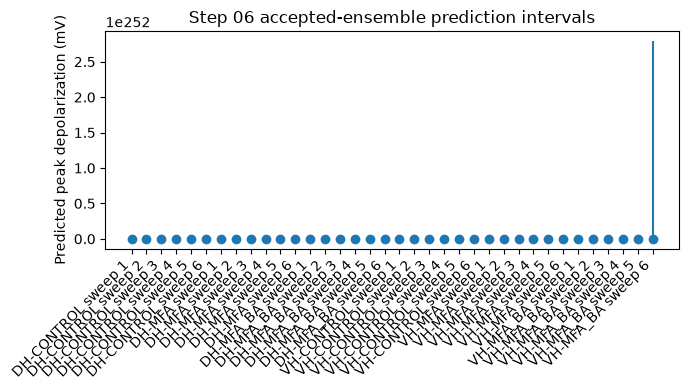

In [6]:
plot_df = intervals[intervals["feature"] == "peak_depolarization_mV"].copy()
fig, ax = plt.subplots(figsize=(7, 4))
if not plot_df.empty:
    labels = plot_df["region"].astype(str) + "-" + plot_df["condition"].astype(str) + " sweep " + plot_df["sweep"].astype(str)
    x = range(len(plot_df))
    ax.errorbar(x, plot_df["pi_median"], yerr=[plot_df["pi_median"] - plot_df["pi_lower"], plot_df["pi_upper"] - plot_df["pi_median"]], fmt="o")
    ax.set_xticks(list(x))
    ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_ylabel("Predicted peak depolarization (mV)")
ax.set_title("Step 06 accepted-ensemble prediction intervals")
fig.tight_layout()

## Feature posterior predictive coverage

In [7]:
ppc = result["feature_distribution_ppc"]
ppc.sort_values(["region", "condition", "sweep", "feature"]).head(15)

,region,condition,sweep,feature,n_predictions,empirical_lower,empirical_upper,coverage_fraction,reliability_weight,weighted_coverage,threshold_fallback
0,DH,CONTROL,1,decay_slope_mV_per_s,7,-0.919971,19.346905,1.000000,1.000000,1.000000,region_specific
1,DH,CONTROL,1,decay_tau_s,7,0.003572,0.606210,0.000000,1.000000,0.000000,region_specific
2,DH,CONTROL,1,peak_depolarization_mV,7,5.260867,9.464395,0.000000,0.500000,0.000000,region_specific
3,DH,CONTROL,1,plateau_slope_mV_per_s,7,-0.071938,0.044090,0.857143,1.000000,0.857143,region_specific
4,DH,CONTROL,1,return_slope_mV_per_s,7,0.026767,0.035590,0.000000,0.928571,0.000000,region_specific
5,DH,CONTROL,1,rise_slope_mV_per_s,7,-1.456547,15.727173,1.000000,1.000000,1.000000,region_specific
6,DH,CONTROL,1,rise_tau_s,7,-0.005953,0.740964,0.000000,1.000000,0.000000,region_specific
7,DH,CONTROL,1,stim_end_depolarization_mV,7,4.569925,9.574925,0.857143,0.500000,0.428571,region_specific
8,DH,CONTROL,1,undershoot_magnitude_mV,7,-0.684730,2.759430,1.000000,1.000000,1.000000,region_specific
9,DH,CONTROL,2,decay_slope_mV_per_s,7,-3.079960,29.092385,1.000000,1.000000,1.000000,region_specific


## Perturbation robustness

In [8]:
perturb = result["perturbation_sweeps"]
perturb_cols = [
    "file_id", "region", "condition", "mechanism_cluster", "buffering_phenotype",
    "current_na", "perturbation", "K_o_peak", "K_o_recovery_error",
    "Vm_feature_pass_fraction", "hidden_flux_plausible", "robust_under_perturbation",
    "perturbation_status", "simulation_status",
]
perturb[perturb_cols].head(30)

,file_id,region,condition,mechanism_cluster,buffering_phenotype,current_na,perturbation,K_o_peak,K_o_recovery_error,Vm_feature_pass_fraction,hidden_flux_plausible,robust_under_perturbation,perturbation_status,simulation_status
0,1_DH_1_CONTROL,DH,CONTROL,M1,mixed_local_spatial_buffering,50,nominal,6.399778,0.007583,0.555556,True,True,evaluated,ok
1,1_DH_1_CONTROL,DH,CONTROL,M1,mixed_local_spatial_buffering,50,eps_scale_low,6.399556,0.015146,0.555556,True,True,evaluated,ok
2,1_DH_1_CONTROL,DH,CONTROL,M1,mixed_local_spatial_buffering,50,eps_scale_high,6.399889,0.003794,0.555556,True,True,evaluated,ok
3,1_DH_1_CONTROL,DH,CONTROL,M1,mixed_local_spatial_buffering,50,stimulus_duration_short,6.399568,0.008215,0.555556,True,True,evaluated,ok
4,1_DH_1_CONTROL,DH,CONTROL,M1,mixed_local_spatial_buffering,50,stimulus_duration_long,6.399887,0.006684,0.555556,True,True,evaluated,ok
5,1_DH_1_CONTROL,DH,CONTROL,M1,mixed_local_spatial_buffering,50,baseline_K_o_low,6.399778,0.007581,0.555556,True,True,evaluated,ok
6,1_DH_1_CONTROL,DH,CONTROL,M1,mixed_local_spatial_buffering,50,baseline_K_o_high,6.399778,0.008837,0.555556,True,True,evaluated,ok
7,1_DH_1_CONTROL,DH,CONTROL,M1,mixed_local_spatial_buffering,50,current_scale_low,4.816832,0.009431,0.555556,True,True,evaluated,ok
8,1_DH_1_CONTROL,DH,CONTROL,M1,mixed_local_spatial_buffering,50,current_scale_high,7.999023,0.005676,0.444444,True,True,evaluated,ok
9,1_DH_1_CONTROL,DH,CONTROL,M1,mixed_local_spatial_buffering,75,nominal,7.229412,0.006596,0.555556,True,True,evaluated,ok


In [9]:
robustness = result["robustness_summary"]
robustness

,mechanism_cluster,region,condition,n_candidates,n_cells,holdout_pass_fraction,mean_weighted_ppc_coverage,perturbation_robust_fraction,perturbation_vm_feature_pass_fraction,hidden_flux_plausible_fraction,biological_description_score,buffering_phenotype_labels,step05_evidence_status,validation_label,step06_screen_claim,final_biological_degeneracy_claim_allowed,degeneracy_claim_allowed,claim_scope_after_step06
0,M1,DH,CONTROL,7,7,1.0,0.343915,0.708333,0.410053,1.0,0.692460,low_recruitment_local_storage;mixed_local_spat...,candidate_regime_screen,predictive_supported,candidate_regime_supported_by_step06_predictiv...,False,False,candidate_regime_supported_by_step06_predictiv...
1,M1,DH,MFA,2,2,1.0,0.430556,0.468750,0.452050,1.0,0.670271,kir_dominant_local_buffering;mixed_local_spati...,candidate_regime_screen,prediction_limited,mechanism_candidate_not_supported_by_step06_sc...,False,False,mechanism_candidate_not_supported_by_step06_sc...
2,M1,VH,MFA,2,2,1.0,0.179579,0.114583,0.259590,1.0,0.510751,kir_dominant_local_buffering;low_recruitment_l...,candidate_regime_screen,prediction_limited,mechanism_candidate_not_supported_by_step06_sc...,False,False,mechanism_candidate_not_supported_by_step06_sc...
3,M2,DH,MFA,4,4,1.0,0.430556,0.354167,0.563409,1.0,0.669626,available_surface_voltage_coupled_but_ionic_re...,candidate_regime_screen,prediction_limited,mechanism_candidate_not_supported_by_step06_sc...,False,False,mechanism_candidate_not_supported_by_step06_sc...
4,M2,VH,CONTROL,2,2,1.0,0.081481,0.000000,0.109954,1.0,0.438287,kir_dominant_local_buffering;mixed_local_spati...,candidate_regime_screen,prediction_limited,mechanism_candidate_not_supported_by_step06_sc...,False,False,mechanism_candidate_not_supported_by_step06_sc...
5,M2,VH,MFA,5,5,1.0,0.179579,0.145833,0.239947,1.0,0.513072,available_surface_voltage_coupled_but_ionic_re...,candidate_regime_screen,prediction_limited,mechanism_candidate_not_supported_by_step06_sc...,False,False,mechanism_candidate_not_supported_by_step06_sc...
6,M3,DH,MFA_BA,6,6,1.0,0.491855,1.000000,0.588735,1.0,0.816118,available_surface_voltage_coupled_but_ionic_re...,candidate_regime_screen,predictive_supported,candidate_regime_supported_by_step06_predictiv...,False,False,candidate_regime_supported_by_step06_predictiv...
7,M3,VH,MFA_BA,7,7,1.0,0.269652,0.511905,0.333510,1.0,0.623014,kir_dominant_local_buffering;low_recruitment_l...,candidate_regime_screen,predictive_supported,candidate_regime_supported_by_step06_predictiv...,False,False,candidate_regime_supported_by_step06_predictiv...


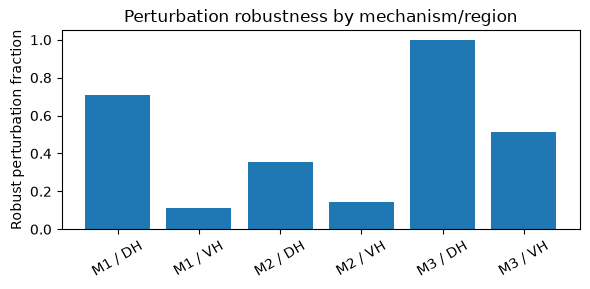

In [10]:
fig, ax = plt.subplots(figsize=(6, 3))
if not robustness.empty:
    robust_plot = robustness.copy()
    robust_plot["label"] = robust_plot["mechanism_cluster"].astype(str) + " / " + robust_plot["region"].astype(str)
    ax.bar(robust_plot["label"], robust_plot["perturbation_robust_fraction"].fillna(0.0))
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Robust perturbation fraction")
    ax.tick_params(axis="x", rotation=30)
ax.set_title("Perturbation robustness by mechanism/region")
fig.tight_layout()

## Claim scope after Step 06

The pipeline reports `predictive_supported`, `prediction_limited`, `fit_only`, or `insufficient_evidence`. It also reports a numerical `biological_description_score` that combines held-out, posterior predictive, perturbation, Vm-feature, and hidden-flux support. This score is an evidence-maturity screen, not a degeneracy claim by itself.

The notebook does **not** upgrade clusters to `candidate_degenerate_regimes` from Step 06 alone; any degeneracy wording requires mechanism distinction plus predictive/perturbation support and later assumption-sensitivity and parameter-plausibility checks.

In [11]:
pd.DataFrame([result["analysis_summary"]])

,step_name,config,n_candidates,n_heldout_rows,n_prediction_interval_rows,n_ppc_rows,n_perturbation_rows,validation_labels,headline_claim_scope,elapsed_seconds
0,Step 06 — Predictive validation and perturbati...,"{'max_candidates': None, 'candidate_policy': '...",35,280,324,324,1890,"[prediction_limited, predictive_supported]",Mechanism regimes require predictive_supported...,72.338051


In [12]:
assert set(perturb["current_na"].dropna().astype(int)) == {50, 75, 100, 125, 150, 175}
duration = perturb[perturb["perturbation"].astype(str).str.startswith("stimulus_duration")]
assert not duration.empty
assert duration["perturbation_status"].eq("evaluated").all()
assert "biological_description_score" in robustness.columns
assert not robustness["final_biological_degeneracy_claim_allowed"].astype(bool).any()
print("Step 06 full-current validation notebook completed across the full cell-level target scope.")

Step 06 full-current validation notebook completed across the full cell-level target scope.


## Candidate-scope sensitivity

This sensitivity screen compares the default best-per-cell Step 06 validation against top-k and mechanism-diverse accepted representatives per cell. It is a scope-control analysis: it can support robustness of a screen, but final biological degeneracy wording remains gated by the conservative claim logic above.


In [13]:
from src.step06_predictive_validation import load_step06_inputs

scope_rows = []
scope_robustness_tables = []
for candidate_policy, candidates_per_cell in [
    ("best_per_cell", 1),
    ("top_k_per_cell", 3),
    ("mechanism_diverse_per_cell", 3),
]:
    scope_config = Step06Config(
        max_candidates=None,
        candidate_policy=candidate_policy,
        candidates_per_cell=candidates_per_cell,
        time_points=50,
        perturbation_current_na=None,
        write_outputs=False,
    )
    scope_candidates, _ = load_step06_inputs(PROJECT_ROOT, scope_config)
    scope_result = run_step06_predictive_validation(PROJECT_ROOT, scope_config)
    scope_robustness = scope_result["robustness_summary"].copy()
    scope_robustness.insert(0, "candidate_policy", candidate_policy)
    scope_robustness.insert(1, "candidates_per_cell", candidates_per_cell)
    scope_robustness_tables.append(scope_robustness)
    scope_rows.append({
        "candidate_policy": candidate_policy,
        "candidates_per_cell": candidates_per_cell,
        "n_candidates": int(len(scope_candidates)),
        "n_cells": int(scope_candidates["file_id"].nunique()),
        "n_robustness_rows": int(len(scope_robustness)),
        "n_predictive_supported_rows": int((scope_robustness["validation_label"].astype(str) == "predictive_supported").sum()),
        "n_prediction_limited_rows": int((scope_robustness["validation_label"].astype(str) == "prediction_limited").sum()),
        "mean_biological_description_score": float(pd.to_numeric(scope_robustness["biological_description_score"], errors="coerce").mean()),
        "mean_perturbation_robust_fraction": float(pd.to_numeric(scope_robustness["perturbation_robust_fraction"], errors="coerce").mean()),
    })

scope_sensitivity_summary = pd.DataFrame(scope_rows)
scope_sensitivity_robustness = pd.concat(scope_robustness_tables, ignore_index=True, sort=False)
reviewer_synthesis_dir = PROJECT_ROOT / "outputs" / "reviewer_synthesis"
reviewer_synthesis_dir.mkdir(parents=True, exist_ok=True)
scope_sensitivity_summary.to_csv(reviewer_synthesis_dir / "step06_candidate_scope_sensitivity_summary.csv", index=False)
scope_sensitivity_robustness.to_csv(reviewer_synthesis_dir / "step06_candidate_scope_sensitivity_robustness.csv", index=False)
scope_sensitivity_summary


,candidate_policy,candidates_per_cell,n_candidates,n_cells,n_robustness_rows,n_predictive_supported_rows,n_prediction_limited_rows,mean_biological_description_score,mean_perturbation_robust_fraction
0,best_per_cell,1,35,35,8,3,5,0.616766,0.412946
1,top_k_per_cell,3,99,35,13,8,5,0.647928,0.522498
2,mechanism_diverse_per_cell,3,84,35,15,10,5,0.664447,0.556614


## Post-execution scientific status

Executed status for reviewer response: Step 06 used one best accepted candidate per represented cell (35 candidates) and evaluated all six canonical currents, producing 280 held-out rows and 1890 perturbation rows. In the canonical best-per-cell screen, 3 mechanism-region-condition groups are `predictive_supported` and 5 remain `prediction_limited`; expanded candidate-scope sensitivity gives 8/13 supported rows for top-3 per cell and 10/15 supported rows for mechanism-diverse top-3 per cell. This strengthens R6 and part of R5 while showing that support improves with candidate diversity, but final biological degeneracy wording remains prohibited because support is not uniform and assumption/parameter checks still constrain the claim.